# NB13 — Reviewer Tables and Figures | NIR-HUEVOS 2026

This notebook converts the frozen NB11–NB12 outputs into publication-ready tables, high-resolution figures, and a machine-generated wording summary. It performs no training and introduces no new model-selection decisions.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
from pathlib import Path
from datetime import datetime, timezone
import json, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT=Path('/content/drive/MyDrive/NIR_HUEVOS_PAPER_REBUILD_2026')
ROUND=PROJECT_ROOT/'05_RESULTS'/'REVISION_REVIEWERS_2026_09'
R11=ROUND/'NB11_CNN1D_REVIEWER_BENCHMARK'
R12=ROUND/'NB12_CLUSTERED_UNCERTAINTY_AND_INFLUENCE'
RESULT_DIR=ROUND/'NB13_REVIEWER_TABLES_FIGURES'
FIG_DIR=PROJECT_ROOT/'06_FIGURES'/'REVISION_REVIEWERS_2026_09'/'NB13_REVIEWER_TABLES_FIGURES'
for p in [RESULT_DIR,FIG_DIR]: p.mkdir(parents=True,exist_ok=True)
for p in [R11/'EXECUTION_STATUS.json',R12/'EXECUTION_STATUS.json']:
    assert p.exists() and json.loads(p.read_text())['status']=='SUCCESS',f'Prerequisite incomplete: {p}'

sns.set_theme(style='whitegrid',context='paper',font_scale=1.2)
palette={'SVR':'#0072B2','PLSR':'#56B4E9','ANN':'#009E73','CNN1D':'#E69F00','SimpleRNN':'#CC79A7','LSTM':'#D55E00','BiLSTM':'#999999'}
print('NB11 and NB12 passed their completion gates.')


NB11 and NB12 passed their completion gates.


In [3]:
# Load final analytical tables
ci=pd.read_csv(R12/'NB12_cluster_bootstrap_metric_CI.csv').sort_values('MAE_days')
diff=pd.read_csv(R12/'NB12_paired_bootstrap_MAE_differences.csv')
tests=pd.read_csv(R12/'NB12_pairwise_wilcoxon_holm.csv')
egg=pd.read_csv(R12/'NB12_per_egg_metrics_long.csv')
influence=pd.read_csv(R12/'NB12_leave_one_egg_out_influence.csv')
influence_summary=pd.read_csv(R12/'NB12_leave_one_egg_out_summary.csv')
fold=pd.read_csv(R12/'NB12_outer_fold_metrics_7models.csv')
oof=pd.read_csv(R12/'NB12_unified_oof_predictions.csv')

table1=ci[['model','MAE_days','MAE_CI_low','MAE_CI_high','RMSE_days','RMSE_CI_low','RMSE_CI_high','R2','R2_CI_low','R2_CI_high']].copy()
table1.to_csv(RESULT_DIR/'Table_R1_performance_7models.csv',index=False)

svr_rows=[]
for model in [m for m in ci.model if m!='SVR']:
    row=diff[((diff.model_a=='SVR')&(diff.model_b==model))|((diff.model_a==model)&(diff.model_b=='SVR'))].iloc[0].copy()
    sign=1 if row.model_a=='SVR' else -1
    t=tests[((tests.model_a=='SVR')&(tests.model_b==model))|((tests.model_a==model)&(tests.model_b=='SVR'))].iloc[0]
    svr_rows.append({
        'comparator':model,'delta_MAE_SVR_minus_comparator':sign*row.delta_MAE_mean,
        'CI_low':min(sign*row.delta_MAE_CI_low,sign*row.delta_MAE_CI_high),
        'CI_high':max(sign*row.delta_MAE_CI_low,sign*row.delta_MAE_CI_high),
        'wilcoxon_p_holm':t.p_holm,'significant_after_Holm':bool(t.reject_holm_0_05)
    })
table2=pd.DataFrame(svr_rows).sort_values('delta_MAE_SVR_minus_comparator')
table2.to_csv(RESULT_DIR/'Table_R2_SVR_paired_comparisons.csv',index=False)
display(table1);display(table2)


,model,MAE_days,MAE_CI_low,MAE_CI_high,RMSE_days,RMSE_CI_low,RMSE_CI_high,R2,R2_CI_low,R2_CI_high
0,SVR,2.194628,2.027259,2.370625,2.716171,2.527328,2.911887,0.816706,0.789339,0.841307
1,PLSR,2.267298,2.083677,2.490164,2.863691,2.619288,3.141824,0.796255,0.754756,0.829549
2,ANN,2.288940,2.096045,2.519131,2.974129,2.722894,3.255320,0.780237,0.736718,0.815798
3,BiLSTM,4.558494,4.228119,4.895744,5.586267,5.125744,6.036512,0.224686,0.094671,0.347248
4,CNN1D,4.571915,4.092267,5.088248,5.623247,5.059596,6.197513,0.214387,0.045735,0.363987
5,LSTM,4.709926,4.516949,4.910556,5.571621,5.369203,5.776828,0.228746,0.170888,0.283768
6,SimpleRNN,4.878542,4.672197,5.079178,5.721820,5.481223,5.956245,0.186603,0.118588,0.253570


,comparator,delta_MAE_SVR_minus_comparator,CI_low,CI_high,wilcoxon_p_holm,significant_after_Holm
5,SimpleRNN,-2.683760,-2.923753,-2.435406,3.911555e-08,True
4,LSTM,-2.514616,-2.775718,-2.253284,3.911555e-08,True
3,CNN1D,-2.378788,-2.868222,-1.890191,3.911555e-08,True
2,BiLSTM,-2.363954,-2.731145,-2.015288,3.911555e-08,True
1,ANN,-0.092815,-0.266502,0.084234,1.000000e+00,False
0,PLSR,-0.071414,-0.216429,0.059247,1.000000e+00,False


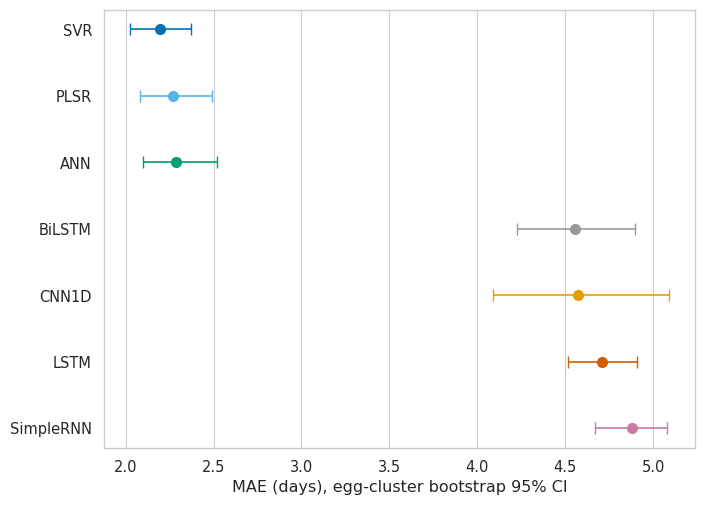

In [4]:
# Figure R1: forest plot of egg-cluster bootstrap MAE confidence intervals
plot=ci.sort_values('MAE_days',ascending=False).reset_index(drop=True)
fig,ax=plt.subplots(figsize=(7.2,5.2))
y=np.arange(len(plot))
for i,r in plot.iterrows():
    ax.errorbar(r.MAE_days,i,xerr=[[r.MAE_days-r.MAE_CI_low],[r.MAE_CI_high-r.MAE_days]],fmt='o',ms=7,capsize=4,color=palette[r.model])
ax.set_yticks(y,plot.model);ax.set_xlabel('MAE (days), egg-cluster bootstrap 95% CI');ax.set_ylabel('')
ax.grid(axis='y',visible=False);fig.tight_layout()
for ext in ['png','svg','pdf']:
    fig.savefig(FIG_DIR/f'Figure_R1_MAE_forest.{ext}',dpi=600 if ext=='png' else None,bbox_inches='tight')
plt.show()


/tmp/ipykernel_3960/1173839400.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=egg,x='model',y='MAE_days',order=order,palette=palette,showfliers=False,ax=ax)


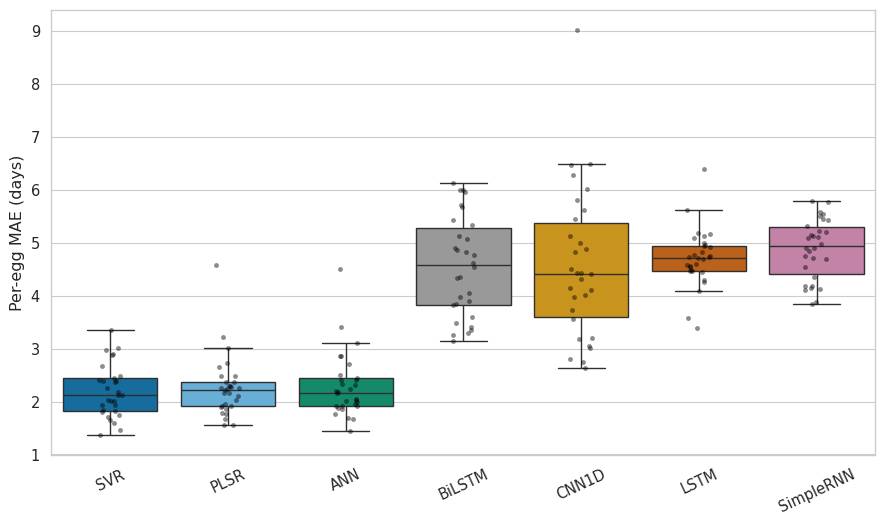

In [5]:
# Figure R2: paired per-egg MAE distributions
order=ci.sort_values('MAE_days').model.tolist()
fig,ax=plt.subplots(figsize=(9,5.4))
sns.boxplot(data=egg,x='model',y='MAE_days',order=order,palette=palette,showfliers=False,ax=ax)
sns.stripplot(data=egg,x='model',y='MAE_days',order=order,color='black',alpha=.45,size=3.5,ax=ax)
ax.set(xlabel='',ylabel='Per-egg MAE (days)');ax.tick_params(axis='x',rotation=25);fig.tight_layout()
for ext in ['png','svg','pdf']:
    fig.savefig(FIG_DIR/f'Figure_R2_per_egg_MAE.{ext}',dpi=600 if ext=='png' else None,bbox_inches='tight')
plt.show()


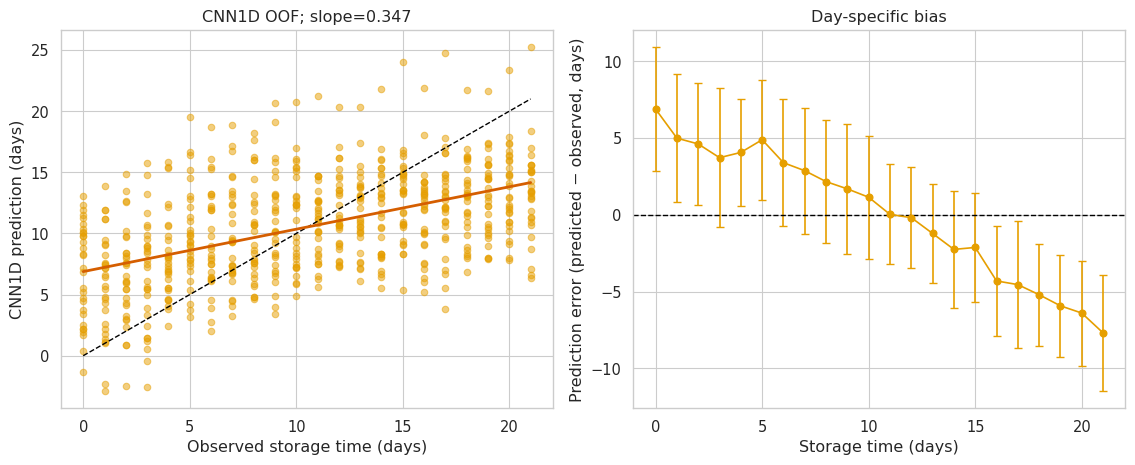

In [6]:
# Figure R3: CNN1D observed vs predicted and day-specific bias
cnn=oof[oof.model=='CNN1D'].copy();cnn['error']=cnn.y_pred-cnn.storage_days
fig,axes=plt.subplots(1,2,figsize=(11.5,4.8))
axes[0].scatter(cnn.storage_days,cnn.y_pred,s=22,alpha=.5,color=palette['CNN1D'])
axes[0].plot([0,21],[0,21],'--',color='black',lw=1)
coef=np.polyfit(cnn.storage_days,cnn.y_pred,1)
axes[0].plot([0,21],np.polyval(coef,[0,21]),color='#D55E00',lw=2)
axes[0].set(xlabel='Observed storage time (days)',ylabel='CNN1D prediction (days)',title=f'CNN1D OOF; slope={coef[0]:.3f}')
day=cnn.groupby('storage_days',as_index=False).agg(mean_error=('error','mean'),sd_error=('error','std'))
axes[1].errorbar(day.storage_days,day.mean_error,yerr=day.sd_error,fmt='o-',capsize=3,color=palette['CNN1D'])
axes[1].axhline(0,color='black',ls='--',lw=1)
axes[1].set(xlabel='Storage time (days)',ylabel='Prediction error (predicted − observed, days)',title='Day-specific bias')
fig.tight_layout()
for ext in ['png','svg','pdf']:
    fig.savefig(FIG_DIR/f'Figure_R3_CNN1D_diagnostics.{ext}',dpi=600 if ext=='png' else None,bbox_inches='tight')
plt.show()


/tmp/ipykernel_3960/827290123.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=influence,x='model',y='delta_MAE_without_minus_full',order=order,palette=palette,showfliers=False,ax=ax)


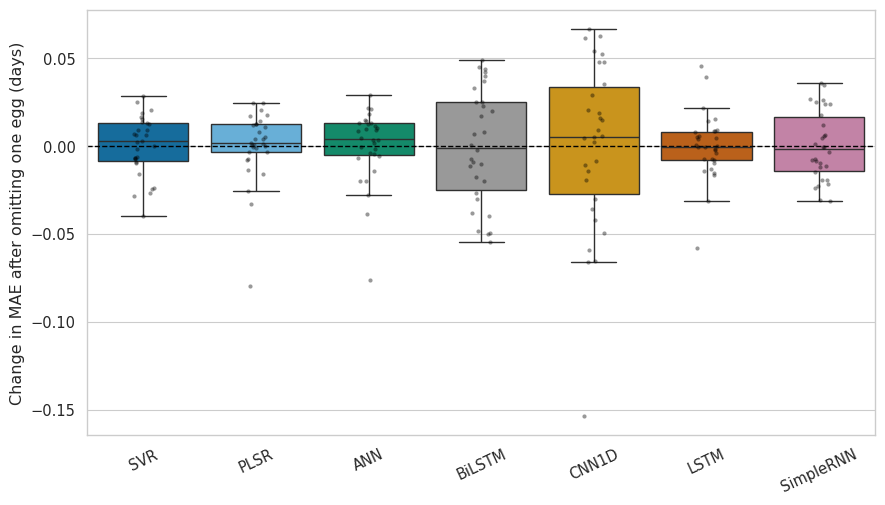

In [7]:
# Figure R4: leave-one-egg-out influence on reported MAE
order=ci.sort_values('MAE_days').model.tolist()
fig,ax=plt.subplots(figsize=(9,5.2))
sns.boxplot(data=influence,x='model',y='delta_MAE_without_minus_full',order=order,palette=palette,showfliers=False,ax=ax)
sns.stripplot(data=influence,x='model',y='delta_MAE_without_minus_full',order=order,color='black',alpha=.4,size=3,ax=ax)
ax.axhline(0,color='black',ls='--',lw=1)
ax.set(xlabel='',ylabel='Change in MAE after omitting one egg (days)')
ax.tick_params(axis='x',rotation=25);fig.tight_layout()
for ext in ['png','svg','pdf']:
    fig.savefig(FIG_DIR/f'Figure_R4_leave_one_egg_influence.{ext}',dpi=600 if ext=='png' else None,bbox_inches='tight')
plt.show()


In [8]:
# Machine-generated exact wording anchors; inspect before copying into the manuscript
cnn=ci[ci.model=='CNN1D'].iloc[0]
best=ci.iloc[0]
fried=pd.read_csv(R12/'NB12_friedman_kendall.csv').iloc[0]
txt=f"""# Reviewer-analysis wording anchors

These sentences are generated directly from saved CSV files. They must be interpreted as an additional reviewer analysis and must not be described as part of the originally frozen NB01–NB10 protocol.

1. Compact CNN result: The leakage-safe compact 1D-CNN achieved MAE = {cnn.MAE_days:.3f} days (egg-cluster bootstrap 95% CI {cnn.MAE_CI_low:.3f}–{cnn.MAE_CI_high:.3f}), RMSE = {cnn.RMSE_days:.3f} days, and R² = {cnn.R2:.3f}.

2. Ranking: The lowest point-estimate MAE among the seven evaluated models was obtained by {best.model} ({best.MAE_days:.3f} days). Point-estimate ranking alone is not interpreted as proof of superiority.

3. Omnibus comparison: The Friedman test across paired per-egg MAE values produced chi-square = {fried.chi_square:.3f}, df = {int(fried.df)}, p = {fried.p_value:.4g}, with Kendall W = {fried.kendall_W:.3f}.

4. Sample-size guardrail: All confidence intervals, paired tests, and influence diagnostics treat the egg as the independent biological unit (N = 30); the 660 longitudinal spectra are not counted as 660 independent replicates.

5. Interpretation guardrail: This additional CNN analysis cannot substitute for external validation across independent egg batches, farms, instruments, temperatures, or acquisition sessions.
"""
(RESULT_DIR/'NB13_reviewer_wording_anchors.md').write_text(txt,encoding='utf-8')
print(txt)


# Reviewer-analysis wording anchors

These sentences are generated directly from saved CSV files. They must be interpreted as an additional reviewer analysis and must not be described as part of the originally frozen NB01–NB10 protocol.

1. Compact CNN result: The leakage-safe compact 1D-CNN achieved MAE = 4.572 days (egg-cluster bootstrap 95% CI 4.092–5.088), RMSE = 5.623 days, and R² = 0.214.

2. Ranking: The lowest point-estimate MAE among the seven evaluated models was obtained by SVR (2.195 days). Point-estimate ranking alone is not interpreted as proof of superiority.

3. Omnibus comparison: The Friedman test across paired per-egg MAE values produced chi-square = 138.529, df = 6, p = 2.048e-27, with Kendall W = 0.770.

4. Sample-size guardrail: All confidence intervals, paired tests, and influence diagnostics treat the egg as the independent biological unit (N = 30); the 660 longitudinal spectra are not counted as 660 independent replicates.

5. Interpretation guardrail: This add

In [9]:
# Completion gate
expected_tables=['Table_R1_performance_7models.csv','Table_R2_SVR_paired_comparisons.csv','NB13_reviewer_wording_anchors.md']
expected_figs=[f'Figure_R{i}_{name}.{ext}' for i,name in [(1,'MAE_forest'),(2,'per_egg_MAE'),(3,'CNN1D_diagnostics'),(4,'leave_one_egg_influence')] for ext in ['png','svg','pdf']]
missing=[str(RESULT_DIR/f) for f in expected_tables if not (RESULT_DIR/f).exists()]+[str(FIG_DIR/f) for f in expected_figs if not (FIG_DIR/f).exists()]
assert not missing,missing
status={'notebook':'NB13_REVIEWER_TABLES_FIGURES.ipynb','status':'SUCCESS','completed_at_utc':datetime.now(timezone.utc).isoformat(),'tables':len(expected_tables),'figures':len(expected_figs),'training_performed':False}
(RESULT_DIR/'EXECUTION_STATUS.json').write_text(json.dumps(status,indent=2),encoding='utf-8')
print('NB13 SUCCESS. Next: NB14_FINAL_RESULTS_PACKAGE.ipynb')


NB13 SUCCESS. Next: NB14_FINAL_RESULTS_PACKAGE.ipynb
